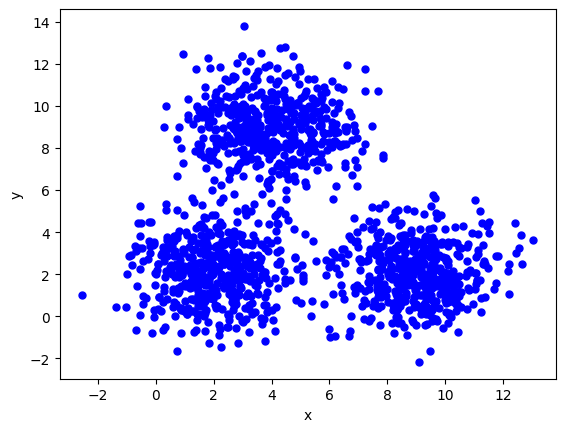

[[ 4.42887424 10.47289368]
 [ 1.98730278  9.30537775]
 [ 3.18237674  1.91737836]]


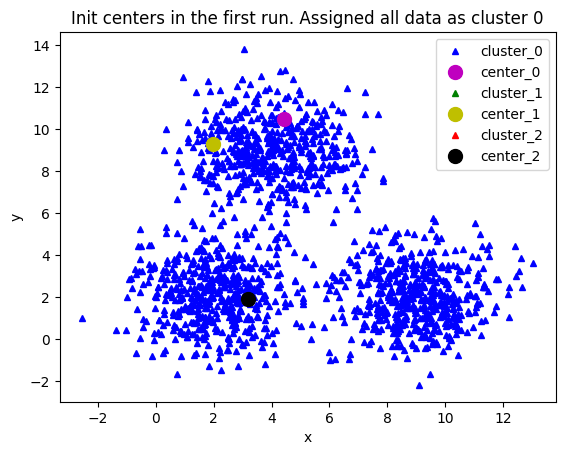

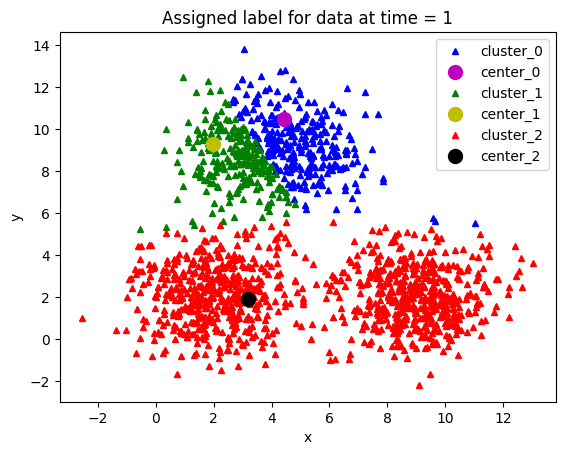

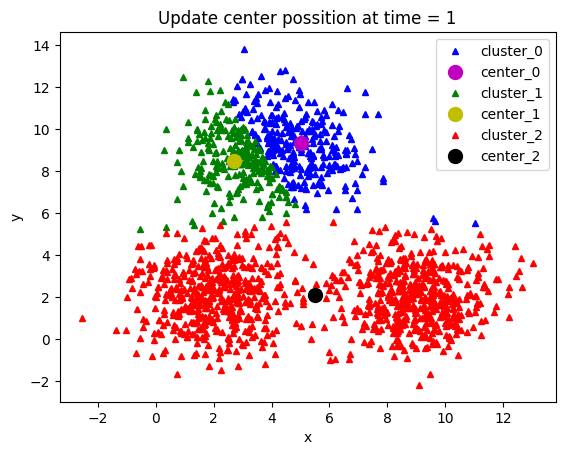

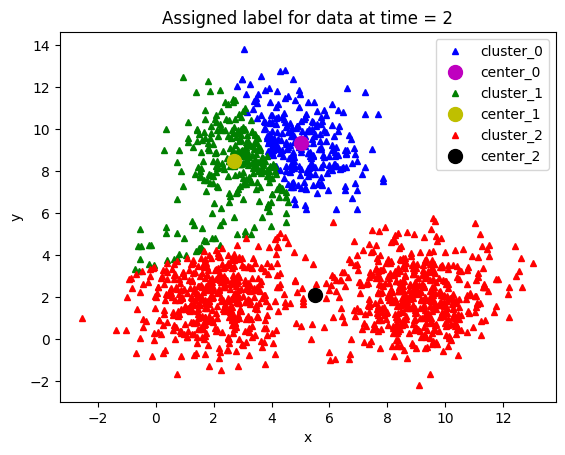

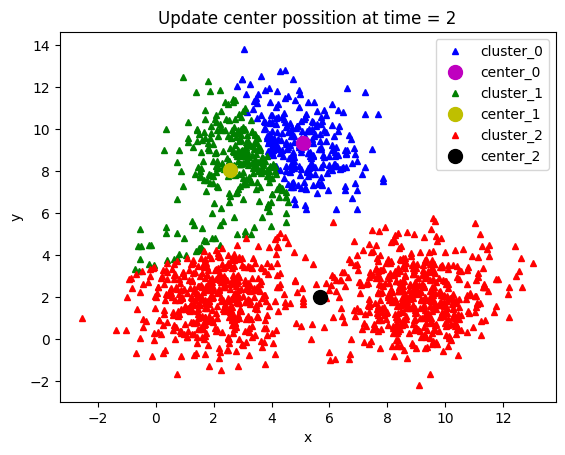

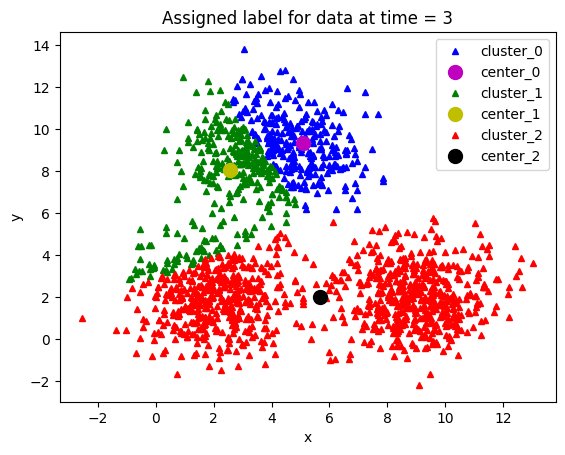

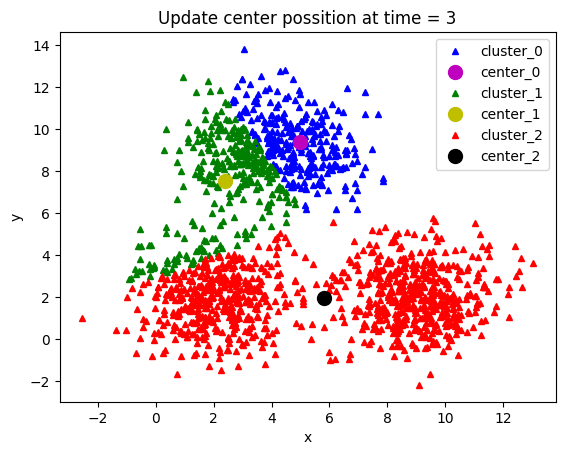

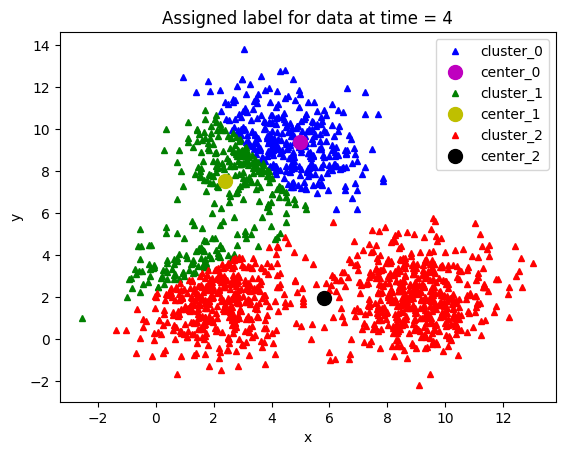

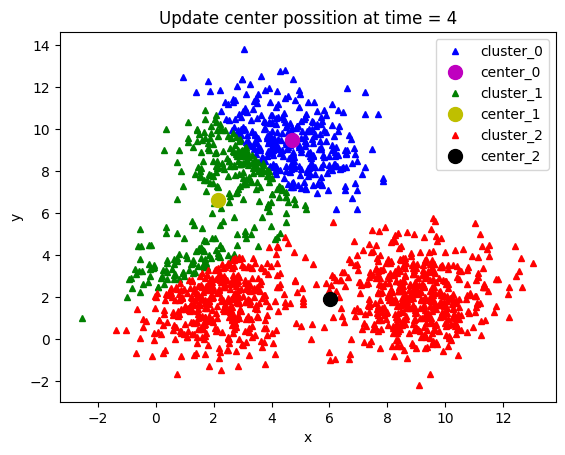

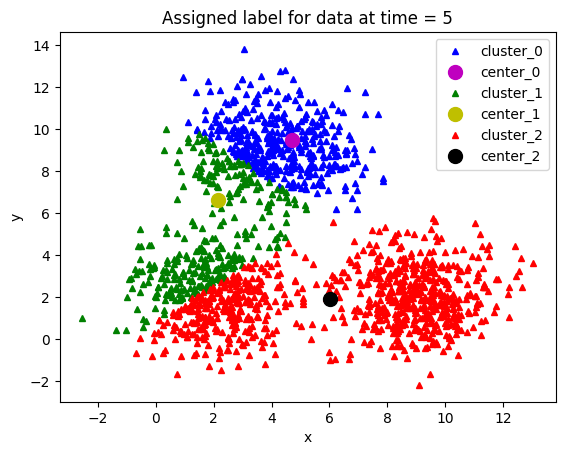

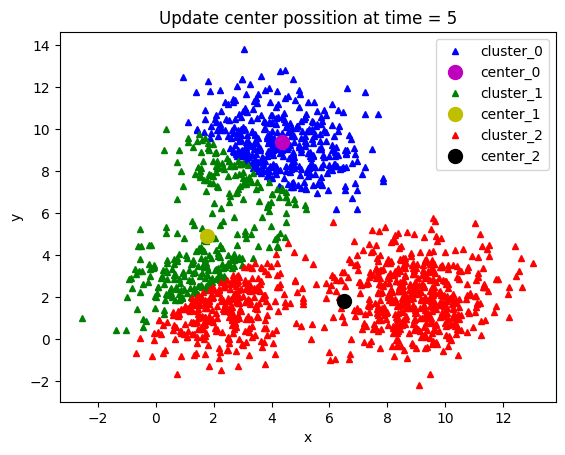

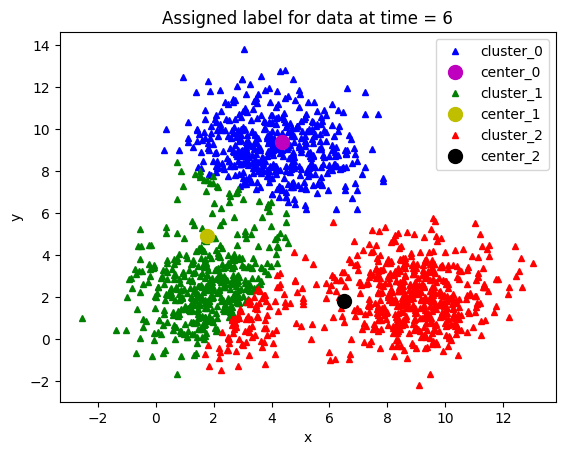

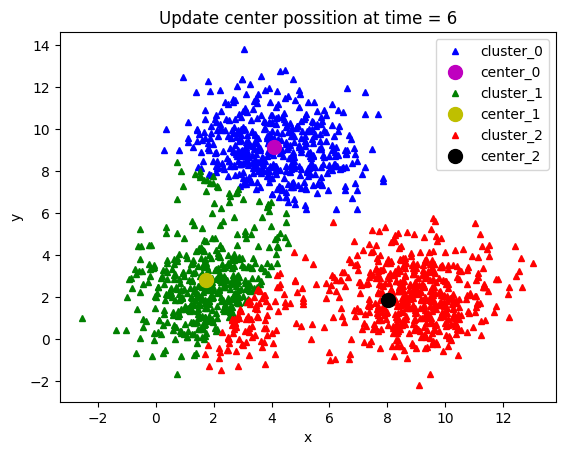

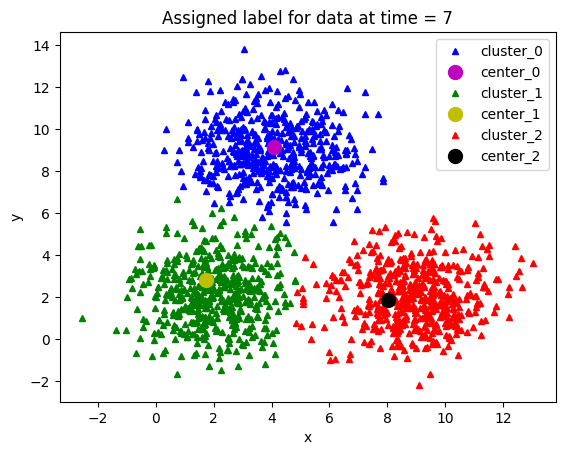

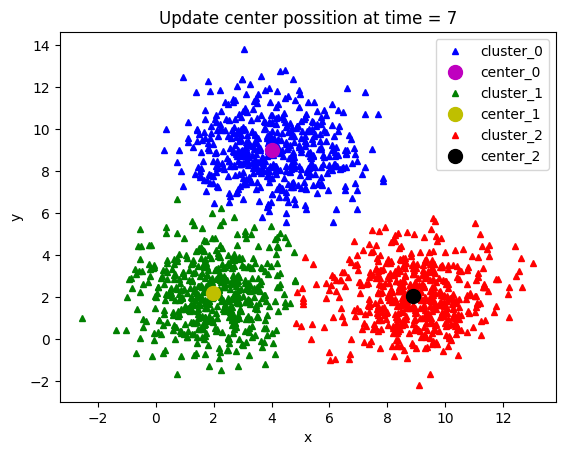

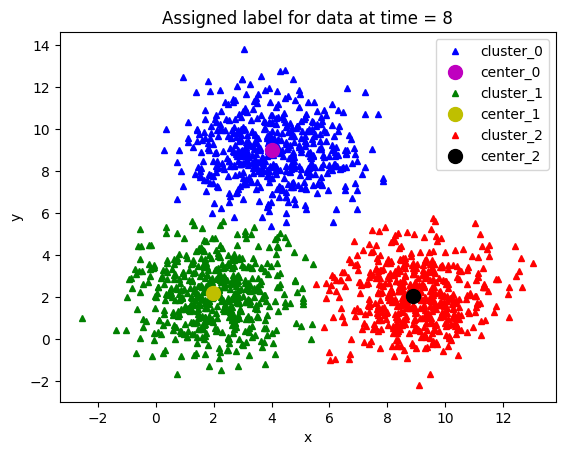

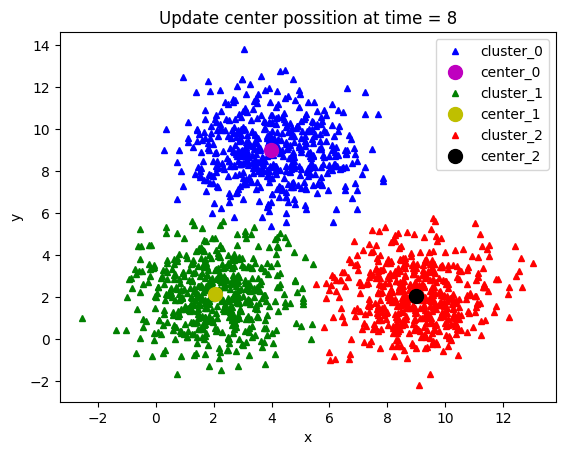

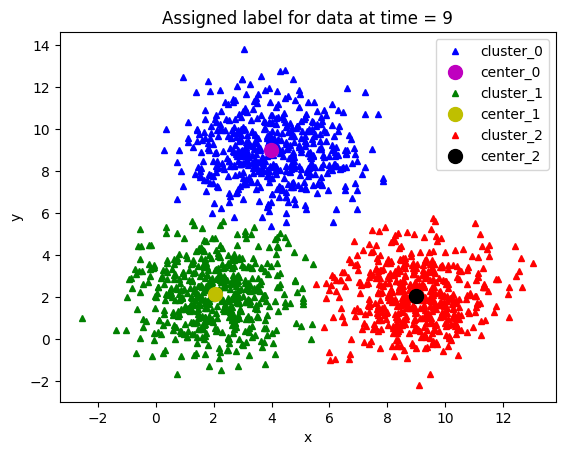

Done! Kmeans has converged after 8 times
[[3.980805   8.98445349]
 [2.02660119 2.14157056]
 [8.9850268  2.06870742]]


In [6]:
import numpy as np # thư viện tính toán toán học
import matplotlib.pyplot as plt # visualize data sử dụng đồ thị
from scipy.spatial.distance import cdist # Hỗ trợ tính khoảng cách
means = [[2, 2], [9, 2], [4, 9]]
cov = [[2, 0], [0, 2]]
n_samples = 500
n_cluster = 3
X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)
X = np.concatenate((X0, X1, X2), axis = 0)
plt.xlabel('x')
plt.ylabel('y')
plt.plot(X[:, 0], X[:, 1], 'bo', markersize=5)
plt.plot()
plt.show()
def kmeans_init_centers(X, n_cluster):
  # random k index beetween 0 and shape(X) without duplicate index.
  # Then return X[index] as cluster
  return X[np.random.choice(X.shape[0], n_cluster, replace=False)]
def kmeans_predict_labels(X, centers):
  D = cdist(X, centers)
  # return index of the closest center
  return np.argmin(D, axis = 1)
def kmeans_update_centers(X, labels, n_cluster):
  centers = np.zeros((n_cluster, X.shape[1]))
  for k in range(n_cluster):
    # collect all points assigned to the k-th cluster
    Xk = X[labels == k, :]
    # take average
    centers[k,:] = np.mean(Xk, axis = 0)
  return centers
def kmeans_has_converged(centers, new_centers):
  # return True if two sets of centers are the same
  return (set([tuple(a) for a in centers]) ==
      set([tuple(a) for a in new_centers]))
# Hàm này dùng để vẽ dữ liệu lên đồ thị
# Random color chỉ làm việc với k <= 4
# Nếu bạn thay đổi k > 4, hãy sửa lại phần random color nhé
# Chỉ sử dụng trong bài toán này thôi nhé.
def kmeans_visualize(X, centers, labels, n_cluster, title):
  plt.xlabel('x')  # label trục x
  plt.ylabel('y')  # label trục y
  plt.title(title)  # title của đồ thị
  plt_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']  # danh sách các màu hỗ trợ

  for i in range(n_cluster):
    data = X[labels == i]  # lấy dữ liệu của cụm i
    plt.plot(data[:, 0], data[:, 1], plt_colors[i] + '^', markersize=4,
             label='cluster_' + str(i))  # Vẽ cụm i lên đồ thị
    plt.plot(centers[i][0], centers[i][1], plt_colors[i + 4] + 'o', markersize=10,
             label='center_' + str(i))  # Vẽ tâm cụm i lên đồ thị
  plt.legend()  # Hiện bảng chú thích
  plt.show()
def kmeans(init_centes, init_labels, X, n_cluster):
  centers = init_centes
  labels = init_labels
  times = 0
  while True:
    labels = kmeans_predict_labels(X, centers)
    kmeans_visualize(X, centers, labels, n_cluster, 'Assigned label for data at time = ' + str(times + 1))
    new_centers = kmeans_update_centers(X, labels, n_cluster)
    if kmeans_has_converged(centers, new_centers):
      break
    centers = new_centers
    kmeans_visualize(X, centers, labels, n_cluster, 'Update center possition at time = ' + str(times + 1))
    times += 1
  return (centers, labels, times)

init_centers = kmeans_init_centers(X, n_cluster)
print(init_centers)  # In ra tọa độ khởi tạo ban đầu của các tâm cụm
init_labels = np.zeros(X.shape[0])
kmeans_visualize(X, init_centers, init_labels, n_cluster,
                 'Init centers in the first run. Assigned all data as cluster 0')
centers, labels, times = kmeans(init_centers, init_labels, X, n_cluster)

print('Done! Kmeans has converged after', times, 'times')
print(centers)


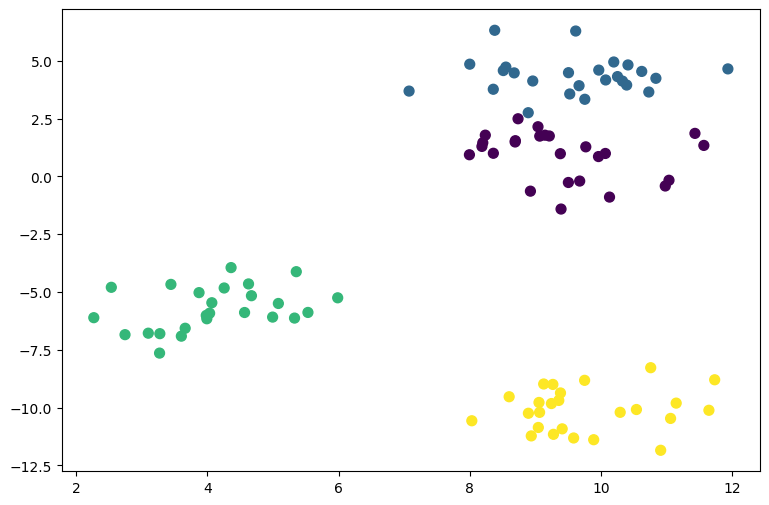

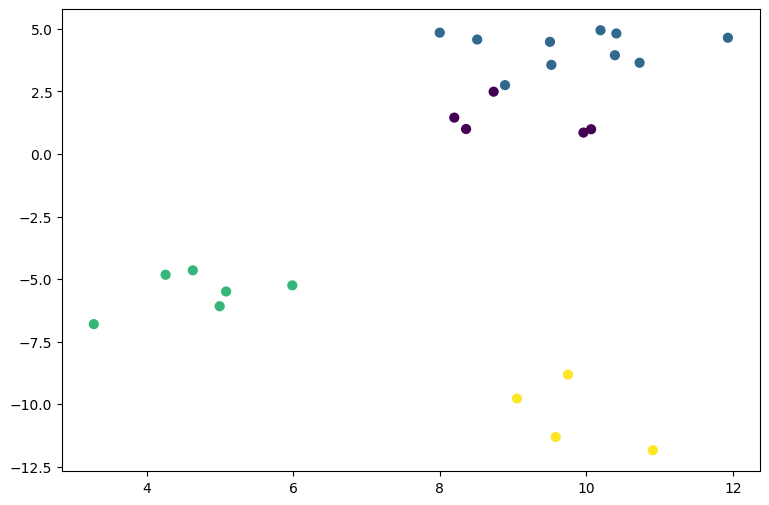

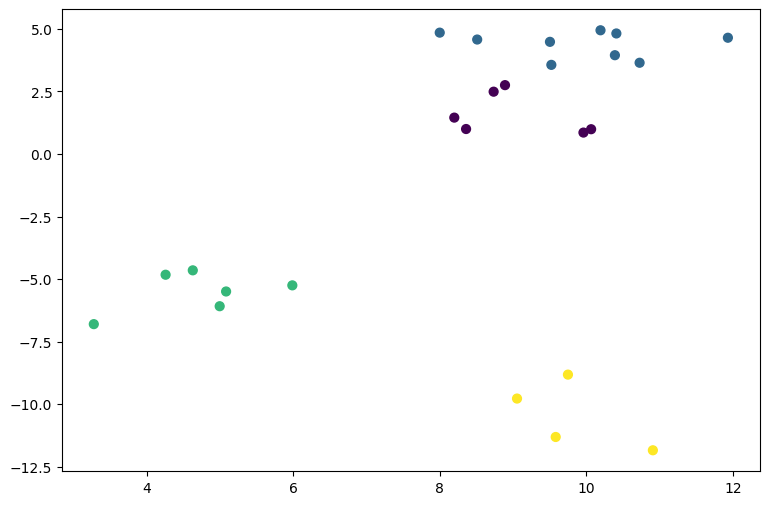

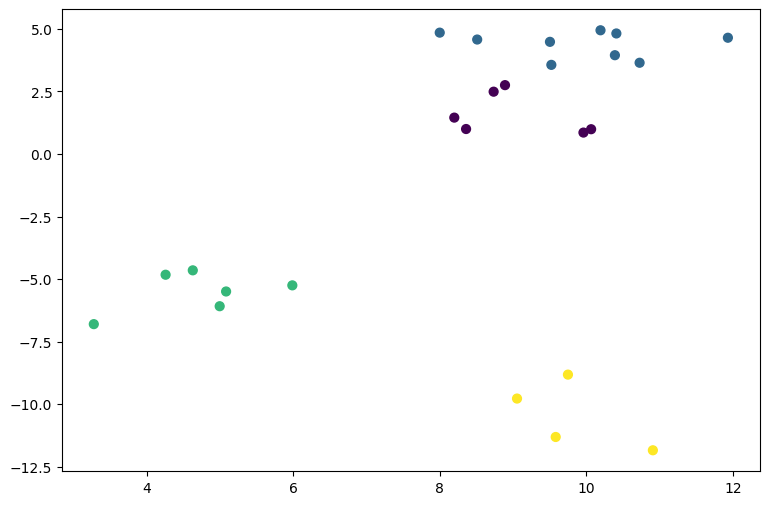

{'n_neighbors': np.int64(2)}
[0]


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # datavisualization
from sklearn.datasets import make_blobs  # synthetic dataset
from sklearn.neighbors import KNeighborsClassifier  # kNN classifier
from sklearn.model_selection import train_test_split  # train and test sets
X,y = make_blobs(n_samples = 100, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)
plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', s=50)
plt.show()
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, marker= 'o', s=40)
plt.show()
knn5 = KNeighborsClassifier(5)  # k=5
knn5.fit(X_train, y_train)

y_pred_5 = knn5.predict(X_test)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_5, marker= 'o', s=40)
plt.show()
knn1 = KNeighborsClassifier(1)  # k=1
knn1.fit(X_train, y_train)

y_pred_1 = knn1.predict(X_test)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_1, marker= 'o', s=40)
plt.show()
from sklearn.model_selection import GridSearchCV

knn_grid = GridSearchCV(estimator = KNeighborsClassifier(), param_grid={'n_neighbors': np.arange(1,10)}, cv=5)
knn_grid.fit(X,y)

print (knn_grid.best_params_)
def KNN(X_train,X_test,y_train,k):
    num_test = X_test.shape[0] # số lượng dữ liệu test
    num_train = X_train.shape[0] # số lượng dữ liệu train
    # y_pred là một ma trận, mỗi hàng tương ứng là khoảng cách của một điểm dữ liệu trong tập test đối với tất cả các điểm dữ liệu trong tập train
    y_pred = np.zeros((num_test,num_train))
    # duyệt qua mỗi điểm trong tập test
    for i in range(num_test):
    # tương ứng một điểm trong tập test sẽ duyêt qua hết bộ train
        for j in range(num_train):
    # tính khoảng cách tới tập train
            y_pred[i,j] = np.sqrt(np.sum(np.power(X_test[i,:]-X_train[j,:],2)))
    results = []
    # sắp xếp theo chiều tăng dần khoảng cách
    for i in range(len(y_pred)):
        zipped = zip(y_pred[i,:],y_train)
        res = sorted(zipped,key = lambda x:x[0])
        results_topk = res[:k]
    # Đếm số lượng của mỗi class
        classes = {}
        for _,j in results_topk:
            j = int(j)
            if j not in classes:
                classes[j] = 1
            else:
                classes[j] = classes[j] + 1
        # trả về class có số lượng nhiều nhất
        results.append(max(classes,key = classes.get))
    return np.array(results)

(X,y) = make_blobs(n_samples = 500, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)
X_test=np.array([(1,3)])
results = KNN(X,X_test,y,3)
print (results)

--- ĐANG KHỞI TẠO ỨNG DỤNG DEMO ---

1. Đang chạy K-Means để phân 3 cụm...
2. Đang tìm tham số K tối ưu cho K-NN...
   => Giá trị K tốt nhất tìm được: 1

--- HOÀN TẤT DEMO ---
Độ chính xác của K-NN dựa trên nhãn của K-Means: 98.75%


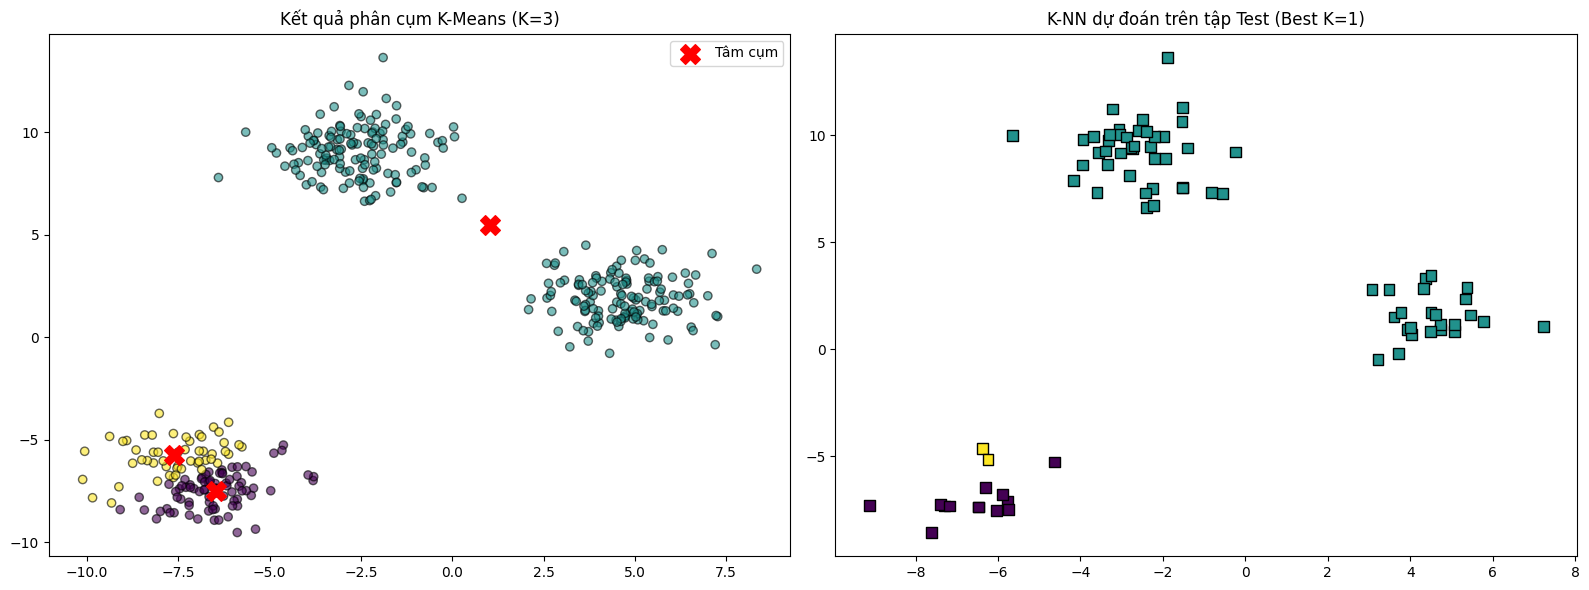

In [8]:
#Bài 3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cdist

# ==========================================
# 1. CÁC HÀM HỖ TRỢ K-MEANS (Từ Bài 1)
# ==========================================
def kmeans_init_centers(X, k):
    return X[np.random.choice(X.shape[0], k, replace=False)]

def kmeans_predict_labels(X, centers):
    D = cdist(X, centers)
    return np.argmin(D, axis=1)

def kmeans_update_centers(X, labels, k):
    centers = np.zeros((k, X.shape[1]))
    for i in range(k):
        Xk = X[labels == i, :]
        centers[i,:] = np.mean(Xk, axis=0)
    return centers

def kmeans_has_converged(centers, new_centers):
    return (set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers]))

def run_kmeans(X, k):
    centers = kmeans_init_centers(X, k)
    while True:
        labels = kmeans_predict_labels(X, centers)
        new_centers = kmeans_update_centers(X, labels, k)
        if kmeans_has_converged(centers, new_centers):
            break
        centers = new_centers
    return centers, labels

# ==========================================
# 2. CÁC HÀM HỖ TRỢ K-NN (Từ Bài 2)
# ==========================================
def find_best_k(X, y):
    param_grid = {'n_neighbors': np.arange(1, 15)}
    grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
    grid.fit(X, y)
    return grid.best_params_['n_neighbors']

# ==========================================
# 3. CHƯƠNG TRÌNH DEMO TỔNG HỢP
# ==========================================
def main_demo():
    print("--- ĐANG KHỞI TẠO ỨNG DỤNG DEMO ---")

    # Bước 1: Tạo dữ liệu ngẫu nhiên
    n_samples = 400
    n_features = 2
    actual_clusters = 3
    X, _ = make_blobs(n_samples=n_samples, centers=actual_clusters, cluster_std=1.2, random_state=42)

    # Bước 2: Chạy K-Means để tự động gán nhãn dữ liệu (Học không giám sát)
    print(f"\n1. Đang chạy K-Means để phân {actual_clusters} cụm...")
    centers, labels = run_kmeans(X, actual_clusters)

    # Bước 3: Sử dụng kết quả K-Means để làm dữ liệu huấn luyện cho K-NN
    X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=10)

    # Bước 4: Tìm K tối ưu cho K-NN bằng GridSearchCV
    print("2. Đang tìm tham số K tối ưu cho K-NN...")
    best_k = find_best_k(X_train, y_train)
    print(f"   => Giá trị K tốt nhất tìm được: {best_k}")

    # Bước 5: Huấn luyện K-NN và dự đoán
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    # Bước 6: Trực quan hóa kết quả
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Đồ thị 1: Kết quả K-Means (Dữ liệu gốc đã phân cụm)
    ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k')
    ax1.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Tâm cụm')
    ax1.set_title(f"Kết quả phân cụm K-Means (K={actual_clusters})")
    ax1.legend()

    # Đồ thị 2: Kết quả K-NN dự đoán trên tập Test
    ax2.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', marker='s', s=60, edgecolors='k')
    ax2.set_title(f"K-NN dự đoán trên tập Test (Best K={best_k})")

    print("\n--- HOÀN TẤT DEMO ---")
    print(f"Độ chính xác của K-NN dựa trên nhãn của K-Means: {knn.score(X_test, y_test)*100:.2f}%")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main_demo()